In [67]:
import numpy as np
import pandas as pd
from bitalg.tests.test2 import Test
import matplotlib.pyplot as plt
from bitalg.visualizer.main import Visualizer

In [68]:
def display_convex_hull(v,points,hull):
    v.clear()
    v.add_point(points)
    v.add_point(hull,color="red")
    v.add_line_segment([(hull[i], hull[i+1]) for i in range(len(hull)-1)],color="red")
    v.add_line_segment([hull[-1], hull[0]],color="red")
    v.show()

In [69]:
def det(a, b, c):
    """
    Obliczanie wyznacznika macierzy 3x3 bez użycia funkcji bibliotecznych
    :param a: krotka współrzędnych (x, y) pierwszego punktu tworzącego naszą prostą
    :param b: krotka współrzędnych (x, y) drugiego punktu tworzącego naszą prostą
    :param c: krotka współrzędnych (x, y) punktu, którego położenie względem prostej chcemy znaleźć
    :return: wartość wyznacznika macierzy
    """
    return a[0]*b[1]+b[0]*c[1] +c[0]*a[1] - b[1]*c[0]-c[1]*a[0]-a[1]*b[0]

In [70]:
EPS = 10 **(-24)
def orient(a,b,c):
    r = det(a,b,c)
    if abs(r) < EPS:
        return 0
    elif r >0: return 1 
    else: return -1

In [71]:
def Andrew(Q):
    #sortuje po x jeśli jest remis to po y
    Q.sort(key = lambda point: (point[0], point[1]))
    U = []
    L = []
    n = len(Q)
    #kolejność wyznacznia łańcuchów zapewnia 
    # że wynik punktów do otoczki będzie przeciwnie du ruch wskazówek zegara
    for i in range(n):
        # Sprawdzenie czy nie tworzą skrętu w lewo
        while len(L) > 1 and not (orient(L[-2], L[-1], Q[i])==1):
            L.pop()
        L.append(Q[i])
    for i in range(n-1, -1,-1):
        # Sprawdzenie czy nie tworzą skrętu w lewo
        while len(U) > 1 and not (orient(U[-2], U[-1], Q[i])==1):
            U.pop()
        U.append(Q[i])
    U.pop()
    L.pop()
    convex_hull  = L + U
    return convex_hull


In [72]:
def generate_uniform_points(left=-100, right=100, n=100):
    """
    Funkcja generuje równomiernie n punktów na kwadwratowym
    obszarze od left do right (jednakowo na osi y)
    o współrzędnych rzeczywistych
    :param left: lewy kraniec przedziału
    :param right: prawy kraniec przedziału
    :param n: ilość generowanych punktów
    :return: tablica punktów w postaci krotek współrzędnych
             np. [(x1, y1), (x2, y2), ... (xn, yn)]
    """
    result = [None for _ in range(n)]
    for i in range(n):
        result[i] = (np.random.uniform(left, right), np.random.uniform(left, right))
    return result


In [86]:
test = [(-78.76088357215785, 29.86704832092201),
 (-26.023112255724996, -59.59652762959762),
 (53.26485902461181, 95.71695525080776),
 (-74.24539609725606, -92.94721268182128),
 (85.23500451948576, -49.21313503964626),
 (-17.641790667150033, 28.638719183806813),
 (91.97819272290434, 51.88914680694958),
 (-91.10469678293344, -96.15155826966885),
 (-14.012598095156065, 77.67850144563096),
 (53.51849914486232, -7.228370987109713),
 (-33.6279657931924, -10.111524806178025),
 (8.0701735803014, -35.58509714166331),
 (-65.01867257524931, -69.85853766724543),
 (81.28402456318875, 71.32981122720821),
 (22.877169918691195, 10.883466710341509),
 (95.67635406518639, -69.0469461779599),
 (81.15312384305577, 81.20176282587522),
 (38.29279181361531, 6.165888256817837),
 (50.36027864507676, 47.13636771024531),
 (-28.689885170885972, -12.346425140188046),
 (31.071087738438507, -2.631015140537613),
 (95.7432750081826, 46.51644802841278),
 (9.920694292588905, -45.883841495327715),
 (83.24133757775368, 91.80451752060011),
 (3.8840936501290315, 25.51137145512999),
 (21.325064446508236, -7.547600461877437),
 (59.96427085588431, -95.3122600885418),
 (8.940225822259734, -39.944109684548025),
 (-79.24246524762819, -86.44082156094859),
 (-14.355173762251866, 11.55822990519195),
 (-46.42630661761387, -11.581706507763244),
 (77.54036547829782, 6.878990259364386),
 (-37.14581358920772, 27.445704727960802),
 (22.754870893870276, -10.999745419403936),
 (1.77389042825709, -38.564321704814965),
 (-93.33148651071038, 74.01261238371174),
 (33.86565689093365, 41.63240289027311),
 (62.07819113387205, -93.18274586488667),
 (53.35186465096959, -47.90721703705356),
 (64.9553775407436, 59.20533405755023),
 (-71.29978079618122, -75.61911331211078),
 (36.69629892133278, 21.389213147210498),
 (71.4658000040391, -8.065049901618181),
 (62.19450216390749, 57.20695711636108),
 (-75.34340919101861, 63.22881171316615),
 (-38.00746089053932, -51.596200073341336),
 (6.683989962629894, 40.46825714217158),
 (-29.019051122209348, 13.393795510921436),
 (-71.82558464207258, -84.20605139437791),
 (30.31088582540022, -41.51697300092272),
 (2.608383168230361, -28.870217279596844),
 (-75.93426049070393, -11.175268359003667),
 (17.07582179853044, 74.31911741969489),
 (-24.094847246481393, -7.99645260481816),
 (82.58109939945115, 49.630056012871336),
 (29.03255913209827, 20.658434799654117),
 (3.0187453795945913, -15.781207507409633),
 (62.83038402225404, 9.724501855753019),
 (50.330361676109504, -99.62614267158337),
 (73.1103308888811, -81.56025036361444),
 (-38.47828354723251, 1.504374063337039),
 (18.244940920770063, 33.85702931576725),
 (-28.61118238608975, -17.957717634770518),
 (-63.046958995209245, -75.6683492261147),
 (72.91576388427728, 83.64155395842911),
 (-49.841141958047984, 35.79339673947965),
 (71.52236265044994, 61.93634009655156),
 (-29.928417446408062, -12.391390136407026),
 (-8.361617459312257, -26.33907299589889),
 (51.933103572397755, -29.64471245415858),
 (39.83306091052552, -36.73523869173045),
 (-56.021977750324666, -14.313354045317396),
 (-54.5399149884932, -79.94920920465984),
 (-58.61162128663386, -41.55274921293313),
 (10.749124885308703, 0.3794647834388627),
 (79.61379474820959, 61.52077378587359),
 (60.63349131218615, -79.43681012734625),
 (86.80574869566948, 6.2114681097427535),
 (41.51134584971763, -11.751824777764682),
 (95.57910963428918, 8.70764216365869),
 (-12.455845778867584, 98.5165872962703),
 (-83.86671143908407, 59.382500289941305),
 (-53.941492012806556, -50.38556602091071),
 (23.089518292289142, 37.29766479750103),
 (73.21330840489898, -28.923756953367572),
 (87.62847368383584, 90.76077945403333),
 (35.737675036120095, 3.9469453196343807),
 (94.3910898333477, -46.59150823668779),
 (-20.821157949878327, -25.29803718328749),
 (25.859177142829964, -61.11258476569359),
 (-4.643918751097303, 84.3713402118886),
 (-72.09647282805244, 29.43449590345523),
 (77.88107887332609, 11.584113134603541),
 (-76.37673824713067, 96.62300740984472),
 (-78.70886148928003, -38.50003093589876),
 (-59.025894743122386, -74.31254488140226),
 (77.45282419028734, -24.91631512494763),
 (80.42093963146687, -77.21562210409236),
 (76.1488370106363, 15.639591927446489),
 (-58.45150884665937, 51.70740251277809)]
points_a = generate_uniform_points(-100, 100, 10)

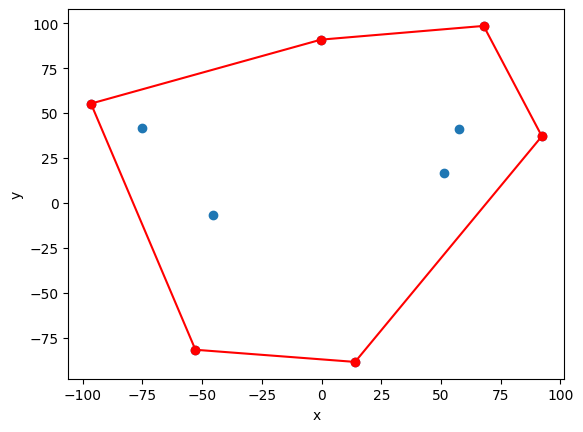

In [87]:
vis = Visualizer()
CH = Andrew(points_a)
display_convex_hull(vis, points_a, CH)

In [88]:
def Andrew_vis(Q):
    v = Visualizer()
    v.add_point(Q, color = "blue")
    #sortuje po x jeśli jest remis to po y
    Q.sort(key = lambda point: (point[0], point[1]))
    U = []
    L = []
    n = len(Q)
    edges = []
    #kolejność wyznacznia łańcuchów zapewnia 
    # że wynik punktów do otoczki będzie przeciwnie du ruch wskazówek zegara
    for i in range(n):
        # Sprawdzenie czy nie tworzą skrętu w lewo
        v.add_point(Q[i], color="green")
        if len(L)>0:
            edges.append(v.add_line_segment([L[-1], Q[i]], color="green"))
        while len(L) > 1 and not (orient(L[-2], L[-1], Q[i])==1):
            v.remove_figure(edges.pop())
            v.remove_figure(edges.pop())
            x = L.pop()
            v.add_point(x, color="blue")
            edges.append(v.add_line_segment([L[-1], Q[i]], color="green"))
        L.append(Q[i])
    edges = []
    for i in range(n-1, -1,-1):
        v.add_point(Q[i], color="red")
        if len(U)>0:
            edges.append(v.add_line_segment([U[-1], Q[i]], color="red"))
        # Sprawdzenie czy nie tworzą skrętu w lewo
        while len(U) > 1 and not (orient(U[-2], U[-1], Q[i])==1):
            v.remove_figure(edges.pop())
            v.remove_figure(edges.pop())
            x = U.pop()
            v.add_point(x, color="blue")
            edges.append(v.add_line_segment([U[-1], Q[i]], color="red"))
        U.append(Q[i])
    U.pop()
    L.pop()
    convex_hull  = L + U
    return convex_hull, v

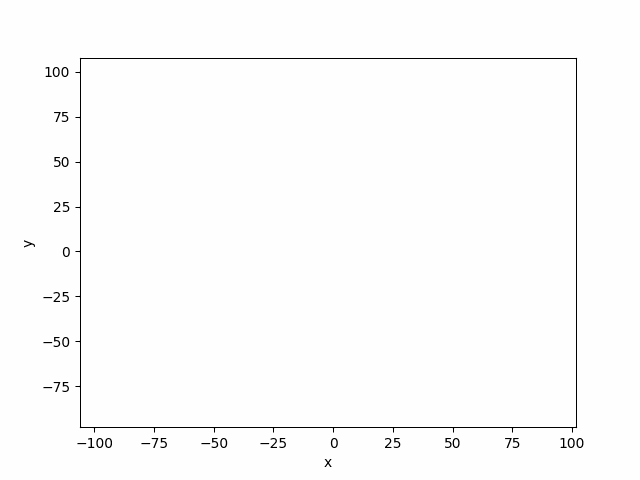

In [89]:
ch, v = Andrew_vis(points_a)
v.show_gif()